In [2]:
import pandas as pd

file_path = "week 4.xlsx"

df = pd.read_excel(file_path, sheet_name="Sheet2")

df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,VerifiedPrice
0,ORD200152,2025-01-02,C77736,Chair,2,399.04,659 Main St,Cash,Cancelled,TRK90329250,3,FREESHIP,Referral,798.08,798.08
1,ORD201141,2025-02-16,C11998,Chair,3,498.66,382 Main St,Cash,Cancelled,TRK26707221,6,No Coupon,Email,1495.98,1495.98
2,ORD200469,2023-11-26,C13877,Chair,5,676.98,893 Main St,Cash,Cancelled,TRK17254691,5,No Coupon,Facebook,3384.90,3384.90
3,ORD200484,2024-05-29,C29092,Chair,4,15.01,767 Main St,Cash,Cancelled,TRK90455340,6,No Coupon,Facebook,60.04,60.04
4,ORD201151,2023-01-29,C94381,Chair,2,608.04,962 Main St,Cash,Cancelled,TRK69804304,4,No Coupon,Google,1216.08,1216.08


In [3]:
df.shape

(1200, 15)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   object        
 1   Date             1200 non-null   datetime64[ns]
 2   CustomerID       1200 non-null   object        
 3   Product          1200 non-null   object        
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   object        
 7   PaymentMethod    1200 non-null   object        
 8   OrderStatus      1200 non-null   object        
 9   TrackingNumber   1200 non-null   object        
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       1200 non-null   object        
 12  ReferralSource   1200 non-null   object        
 13  TotalPrice       1200 non-null   float64       
 14  VerifiedPrice    1200 non-null   float64

In [5]:
df.isnull().sum()

,0
OrderID,0
Date,0
CustomerID,0
Product,0
Quantity,0
UnitPrice,0
ShippingAddress,0
PaymentMethod,0
OrderStatus,0
TrackingNumber,0


In [6]:
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,VerifiedPrice
0,ORD200152,2025-01-02,C77736,Chair,2,399.04,659 Main St,Cash,Cancelled,TRK90329250,3,FREESHIP,Referral,798.08,798.08
1,ORD201141,2025-02-16,C11998,Chair,3,498.66,382 Main St,Cash,Cancelled,TRK26707221,6,No Coupon,Email,1495.98,1495.98
2,ORD200469,2023-11-26,C13877,Chair,5,676.98,893 Main St,Cash,Cancelled,TRK17254691,5,No Coupon,Facebook,3384.90,3384.90
3,ORD200484,2024-05-29,C29092,Chair,4,15.01,767 Main St,Cash,Cancelled,TRK90455340,6,No Coupon,Facebook,60.04,60.04
4,ORD201151,2023-01-29,C94381,Chair,2,608.04,962 Main St,Cash,Cancelled,TRK69804304,4,No Coupon,Google,1216.08,1216.08


In [7]:
df.groupby('Product')['TotalPrice'].sum().sort_values(ascending=False)

,TotalPrice
Product,
Chair,195620.11
Printer,195612.61
Laptop,192126.56
Tablet,186568.95
Monitor,175651.41
Desk,167459.93
Phone,151722.39


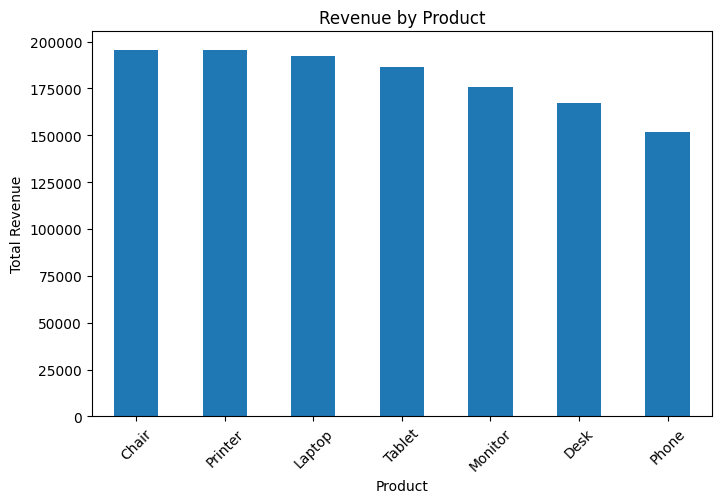

In [8]:
import matplotlib.pyplot as plt

product_sales = df.groupby('Product')['TotalPrice'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
product_sales.plot(kind='bar')
plt.title('Revenue by Product')
plt.xlabel('Product')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.show()

In [9]:
df['PaymentMethod'].value_counts()

,count
PaymentMethod,
Online,258
Cash,246
Credit Card,234
Debit Card,232
Gift Card,230


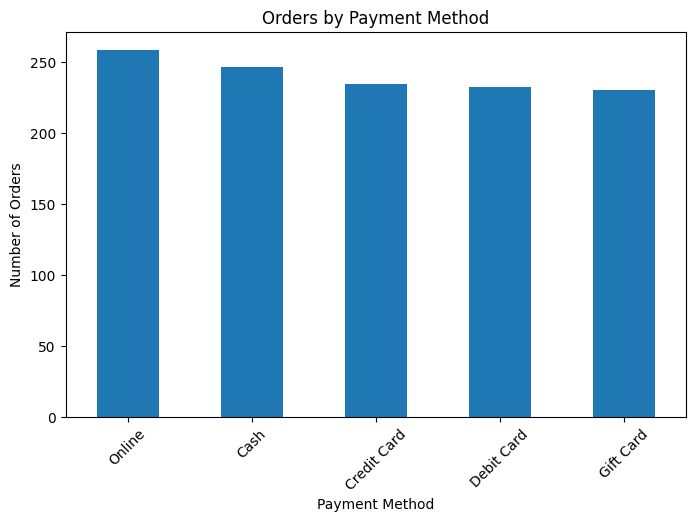

In [10]:
import matplotlib.pyplot as plt

payment_counts = df['PaymentMethod'].value_counts()

plt.figure(figsize=(8,5))
payment_counts.plot(kind='bar')
plt.title('Orders by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.show()

In [12]:
df['OrderStatus'].value_counts()

,count
OrderStatus,
Cancelled,250
Returned,247
Pending,237
Shipped,235
Delivered,231


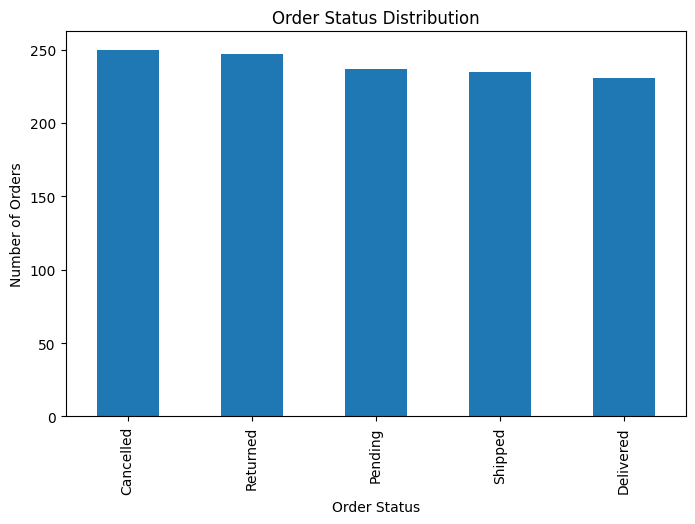

In [13]:
status_counts = df['OrderStatus'].value_counts()

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
status_counts.plot(kind='bar')
plt.title('Order Status Distribution')
plt.xlabel('Order Status')
plt.ylabel('Number of Orders')
plt.show()

In [14]:
df.groupby('ReferralSource')['TotalPrice'].sum().sort_values(ascending=False)

,TotalPrice
ReferralSource,
Instagram,275285.45
Email,261808.55
Google,250441.48
Facebook,250410.90
Referral,226815.58


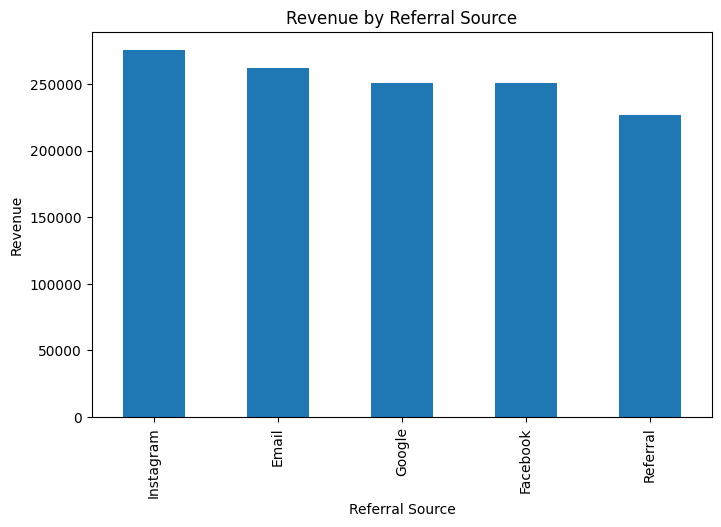

In [15]:
referral_revenue = df.groupby('ReferralSource')['TotalPrice'].sum().sort_values(ascending=False)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
referral_revenue.plot(kind='bar')
plt.title('Revenue by Referral Source')
plt.xlabel('Referral Source')
plt.ylabel('Revenue')
plt.show()

In [16]:
df['Date'] = pd.to_datetime(df['Date'])

monthly_sales = df.groupby(df['Date'].dt.to_period('M'))['TotalPrice'].sum()

monthly_sales

,TotalPrice
Date,
2023-01,56685.75
2023-02,40117.66
2023-03,48609.37
2023-04,27751.71
2023-05,63836.84
2023-06,49500.19
2023-07,42820.66
2023-08,54352.14
2023-09,29526.67


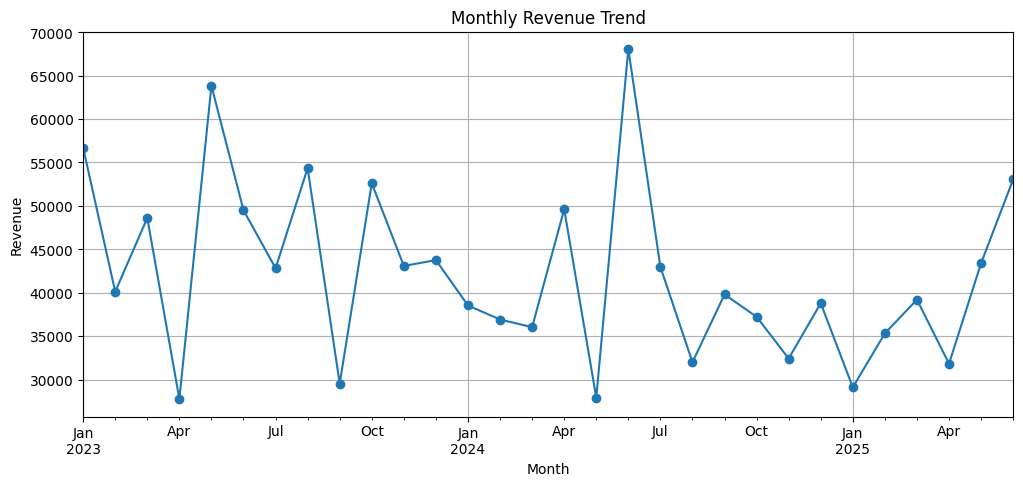

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
monthly_sales.plot(kind='line', marker='o')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.grid(True)
plt.show()

# Key Findings

1. Chair generated the highest revenue among all products, while Phone generated the lowest.

2. Online payment was the most frequently used payment method.

3. Cancelled and Returned orders exceeded Delivered orders, indicating potential operational or customer satisfaction issues.

4. Instagram was the highest revenue-generating referral source, followed by Email marketing.

5. Revenue fluctuated across months, with the highest revenue recorded in June 2024, suggesting possible seasonal trends.

# Recommendations

1. Increase marketing focus on high-performing products such as Chair, Printer, and Laptop.

2. Investigate causes of high cancellation and return rates.

3. Allocate more marketing budget to Instagram and Email campaigns.

4. Analyze factors behind the June 2024 revenue peak and replicate successful strategies.

5. Monitor monthly sales trends to improve forecasting and inventory planning.